## Default setup for a single flap of the FOSWEC

In [29]:
import numpy as np
import os
import xarray as xr
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pygmsh
import capytaine as cpt
from scipy.io import loadmat

import wecopttool as wot

import logging 
logging.getLogger().setLevel(logging.INFO)

In [30]:
# Frequency object
wavefreq    = 1/8 # Hz
f1          = wavefreq
nfreq       = 10
freq        = wot.frequency(f1, nfreq, False) # False -> no zero frequency

# Define waves object
amplitude   = 0.5 # m
phase       = 0 # degrees
wavedir     = 0 # degrees
waves       = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)

INFO:capytaine.io.meshio:Stored 348 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_87"), lid_mesh=None, dofs={}, center_of_mass=[ 0.    0.   -0.42], name="flap1").
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = (0, 0, -0.59)
INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_87 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.


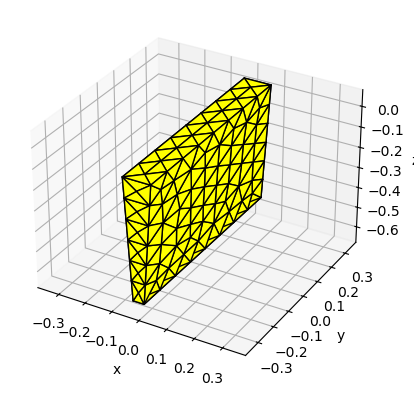

In [31]:
flapThicknessBottom = 0.04
flapThicknessTop    = 0.1
flapCenterDistanceApart = 1.44
flapWidth   = 0.76
flapHeight = 0.58
flapDraft  = 0.59 # 0.53 is based on matching impedance, 0.59 for fully submerged
cgHeightAboveHinge = 0.17
flap1CG     = [0, 0, -flapDraft+cgHeightAboveHinge] # from water surface/origin\


with pygmsh.geo.Geometry() as geom:
    flap1 = geom.add_polygon(
            [[-flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft],
            [-flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft]],mesh_size=0.1)
    geom.extrude(flap1,[0,flapWidth,0])
    flap1Mesh = geom.generate_mesh()

# define the floating body
flap1 = cpt.FloatingBody(mesh=flap1Mesh, name=f'flap1', center_of_mass=flap1CG)

#axis = cpt.Axis(vector=(0, 1, 0), point=(0, 0, -flapDraft))
#flap1.add_rotation_dof(name="Pitch_about_hinge", axis=axis)
#flap1.rotation_center = (0, 0, -flapDraft)

# try specifying cg at hinge so Capytaine calculates hydrostatics around hinge
flap1.center_of_mass = flap1CG
flap1.rotation_center = (0, 0, -flapDraft)
flap1.add_rotation_dof(name='Pitch')

flap_mass = 23.1
flap_inertia_cg = 1.19
flap_inertia_hinge = flap_inertia_cg + flap_mass*cgHeightAboveHinge**2
flap1.mass = flap_mass
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([flap_inertia_hinge]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap1.dofs),
                                    'radiating_dof': list(flap1.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap1.inertia_matrix = rigid_inertia_matrix_xr
flap1.hydrostatic_stiffness = flap1.immersed_part().compute_hydrostatic_stiffness()

flap1.show_matplotlib()
#flap1.show()

In [32]:
# run BEM calculations
bem_data_file = 'foswec_1_flap_WOT.nc'

if os.path.exists(bem_data_file):
    bem_data = wot.read_netcdf(bem_data_file)
else:
    bem_data = wot.run_bem(flap1, freq, depth=2)
    bem_data['radiating_dof'] = bem_data['radiating_dof'].astype(str)
    bem_data['influenced_dof'] = bem_data['influenced_dof'].astype(str)
    wot.write_netcdf(bem_data_file, bem_data) # saves BEM data to file

In [33]:
## PTO impedance definition
omega = bem_data.omega.values
gear_ratio = 3.75
torque_constant = 1.021
winding_resistance = 1.082
winding_inductance = 0.0
drivetrain_inertia = 0.00095
drivetrain_friction = 0.0
drivetrain_stiffness = 0.0

drivetrain_impedance = (1j*omega*drivetrain_inertia +
                        drivetrain_friction +
                        1/(1j*omega)*drivetrain_stiffness)

winding_impedance = winding_resistance + 1j*omega*winding_inductance


pto_impedance_11 = -1* gear_ratio**2 * drivetrain_impedance
off_diag = np.sqrt(3.0/2.0) * torque_constant * gear_ratio
pto_impedance_12 = -1*(off_diag+0j) * np.ones(omega.shape)
pto_impedance_21 = -1*(off_diag+0j) * np.ones(omega.shape)
pto_impedance_22 = winding_impedance
pto_impedance = np.array([[pto_impedance_11, pto_impedance_12],
                            [pto_impedance_21, pto_impedance_22]])

ndof = 1
name = ["flap_pitch",]
kinematics = np.eye(ndof)
controller = wot.controllers.unstructured_controller()
loss = None
pto = wot.pto.PTO(ndof, kinematics, controller, pto_impedance, loss, name)

In [34]:
# PTO dynamics forcing function and drivetrain spring stiffness

def drivetrain_stiffness_torque(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)
    drivetrain_spring = -x_opt[-1]*pos
    spring_torque = jnp.dot(time_matrix, drivetrain_spring)
    return spring_torque

f_add = {'PTO': pto.force_on_wec, 'drivetrain_stiffness': drivetrain_stiffness_torque}

# from Daniel:
# max torque is Kt*46.5 from motor
# max torque is Kt*40 from drive
# Max rms torque is Kt*20 from drive
max_torque = 40*torque_constant
max_rms_torque = 20*torque_constant
max_pos = jnp.pi/2
nsubsteps = 4

def const_motor_torque(wec, x_wec, x_opt, wave): # Format for scipy.optimize.minimize
    pto_torque = pto.force(wec, x_wec, x_opt, wave, nsubsteps)
    motor_torque = pto_torque/gear_ratio
    return max_torque - jnp.abs(motor_torque.flatten())

def const_motor_rms_torque(wec, x_wec, x_opt, wave): # Format for scipy.optimize.minimize
    pto_torque = pto.force(wec, x_wec, x_opt, wave, nsubsteps)
    motor_torque = pto_torque/gear_ratio
    return max_rms_torque - np.sqrt(np.mean(motor_torque**2))

def const_flap_rotation(wec, x_wec, x_opt, wave): # Format for scipy.optimize.minimize
    pos = wec.vec_to_dofmat(x_wec)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)
    pos_td = jnp.dot(time_matrix, pos)
    return max_pos - jnp.abs(pos_td.flatten())

constraints = [{'type': 'ineq', 'fun': const_motor_torque}, {'type': 'ineq', 'fun': const_flap_rotation}]


In [35]:
# create function that loops through values of mass added on top of flap and optimizes control+stiffness
# it should return the new cg height, mass, inertia, hydrostatic_stiffness, maximum position, maximum torque, optimal stiffness, and electrical power

obj_fun = pto.average_power

# add an optimization variable for the stiffness
nstate_opt = 2*nfreq + 1
bounds_opt = tuple([(-1e10, 1e10)] * (nstate_opt - 1) + [(0, 1e10)])

x_wec_0 = np.zeros((2*nfreq,))
x_wec_0 = np.repeat(np.squeeze(waves),2)
x_opt_0 = np.zeros((nstate_opt,))

options = {'maxiter': 200}
scale_x_wec = 1e0
scale_x_opt = 1e-1
scale_obj = 1e0

def add_top_mass(mass_on_top):
    cgHeightAboveHingeNew = (cgHeightAboveHinge*flap_mass + mass_on_top*flapHeight)/(flap_mass + mass_on_top)

    flap1.center_of_mass = [0, 0, -flapDraft+cgHeightAboveHingeNew]
    flap1.rotation_center = (0, 0, -flapDraft)
    flap1.add_rotation_dof(name='Pitch')
 
    flap_inertia_cg_new = flap_inertia_cg + flap_mass*cgHeightAboveHingeNew**2 + mass_on_top*((flapHeight - cgHeightAboveHinge) - cgHeightAboveHingeNew)**2
    flap_inertia_hinge = flap_inertia_cg_new + flap_mass*cgHeightAboveHingeNew**2
    flap1.mass = flap_mass + mass_on_top
    rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([flap_inertia_hinge]))),
                                dims=['influenced_dof', 'radiating_dof'],
                                coords={'influenced_dof': list(flap1.dofs),
                                        'radiating_dof': list(flap1.dofs)},
                                name="inertia_matrix")

    # Set FloatingBody inertia matrix
    flap1.inertia_matrix = rigid_inertia_matrix_xr
    flap1.hydrostatic_stiffness = flap1.immersed_part().compute_hydrostatic_stiffness()
    
    bem_data = wot.run_bem(flap1, freq, depth=2)

    wec = wot.WEC.from_bem(
        bem_data,
        constraints=constraints,
        friction=None,
        f_add=f_add,
    )

    results = wec.solve(
        waves,
        obj_fun,
        nstate_opt,
        optim_options=options,
        scale_x_wec=scale_x_wec,
        scale_x_opt=scale_x_opt,
        scale_obj=scale_obj,
        x_wec_0=x_wec_0,
        x_opt_0=x_opt_0,
        bounds_opt=bounds_opt,
        )

    opt_average_power = results[0].fun
    print(f'Optimal average mechanical power: {opt_average_power} W')

    nsubsteps = 5
    pto_fdom, pto_tdom = pto.post_process(wec, results, waves, nsubsteps=nsubsteps)
    wec_fdom, wec_tdom = wec.post_process(wec, results, waves, nsubsteps=nsubsteps)

    return {
        "mass_on_top": mass_on_top,
        "cg_height": cgHeightAboveHingeNew,
        "total_mass": flap1.mass,
        "inertia_cg": flap_inertia_cg_new,
        "inertia_hinge": flap_inertia_hinge,
        "hydrostatic_stiffness": flap1.hydrostatic_stiffness,
        "max_pos": np.max(wec_tdom.sel(realization=0)['pos']),
        "max_torque": np.max(pto_tdom.sel(realization=0)['force']/gear_ratio),
        "opt_stiffness": results[0].x[-1],
        "opt_power": opt_average_power,
    }

In [36]:
mass_on_top_vec = np.linspace(0,20,21)

all_res = []

for mass_on_top in mass_on_top_vec:
    res = add_top_mass(mass_on_top)
    all_res.append(res)

cg_height_vals = [r["cg_height"] for r in all_res]
mass_vals = [r["total_mass"] for r in all_res]
inertia_vals = [r["inertia_cg"] for r in all_res]
hydrostatic_stiffness_vals = [r["hydrostatic_stiffness"] for r in all_res]
max_pos_vals = [r["max_pos"] for r in all_res]
max_torque_vals = [r["max_torque"] for r in all_res]
opt_stiffness_vals = [r["opt_stiffness"] for r in all_res]
opt_power_vals = [r["opt_power"] for r in all_res]

INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = (0, 0, -0.59)
INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_87 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.green_functions.delhommeau:Loading tabulation from C:\Users\jtgrasb\AppData\Local\capytaine\Cache\2.3.1\tabulation_float64_scaled_nemoh3_676_100.0_372_-251.0_1001.npz


[16:59:26] WARNING  center_of_mass already defined as [0, 0, -0.41999999999999993].

           WARNING  rotation_center already defined as (0, 0, -0.59).

INFO:capytaine.bodies.bodies:Clipping copy_of_flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_87 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.


Output()

...

INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap1_immersed"), omega=6.283, water_depth=2.0, radiating_dof='Pitch', rho=1025.0).
INFO:capytaine.bem.solver:Solve DiffractionProblem(body=FloatingBody(..., name="copy_of_flap1_immersed"), omega=7.069, water_depth=2.0, wave_direction=0.000, rho=1025.0).


INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap1_immersed"), omega=7.069, water_depth=2.0, radiating_dof='Pitch', rho=1025.0).
INFO:capytaine.bem.solver:Solve DiffractionProblem(body=FloatingBody(..., name="copy_of_flap1_immersed"), omega=7.854, water_depth=2.0, wave_direction=0.000, rho=1025.0).


INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_flap1_immersed"), omega=7.854, water_depth=2.0, radiating_dof='Pitch', rho=1025.0).


INFO:capytaine.bem.solver:Solver timer summary:
                     total  nb_calls      mean
task                                          
Solve total       3.300396        20  0.165020
  Green function  2.462295        20  0.123115
  Linear solver   0.732369        20  0.036618
INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [6.19e-01, 2.05e+00, 1.01e+01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [8.65e-01, 7.04e-01, -9.81e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [9.71e-01, 9.49e-01, -3.76e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.13e+00, 1.23e+00, -1.38e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.26e+00, 1.77e+00, -2.15e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.54e+00, 3.40e+00, -3.60e+00]
INFO:wecopttool.core:Scaled [max(x_wec), ma

Optimization terminated successfully    (Exit mode 0)
            Current function value: -3.879655770881026
            Iterations: 17
            Function evaluations: 26
            Gradient evaluations: 17
Optimal average mechanical power: -3.879655770881026 W


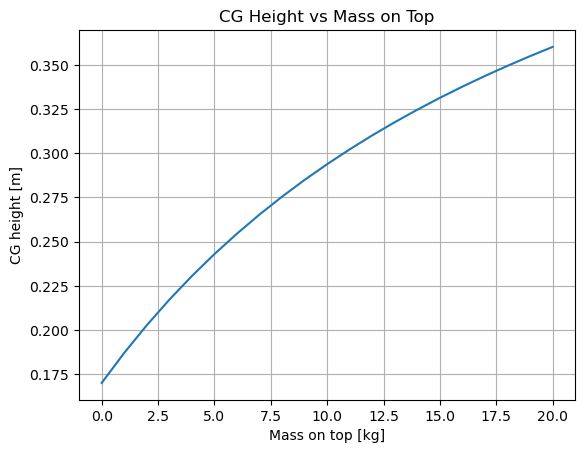

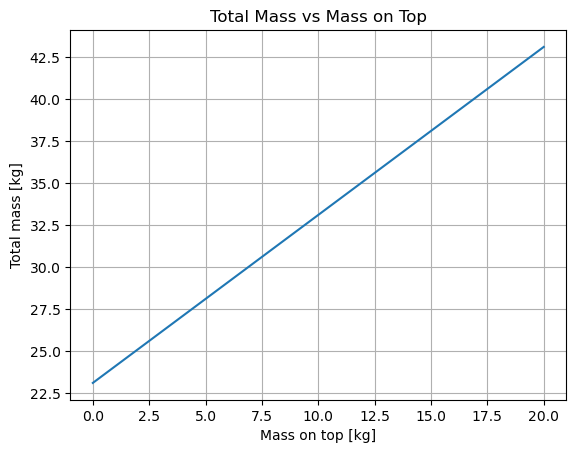

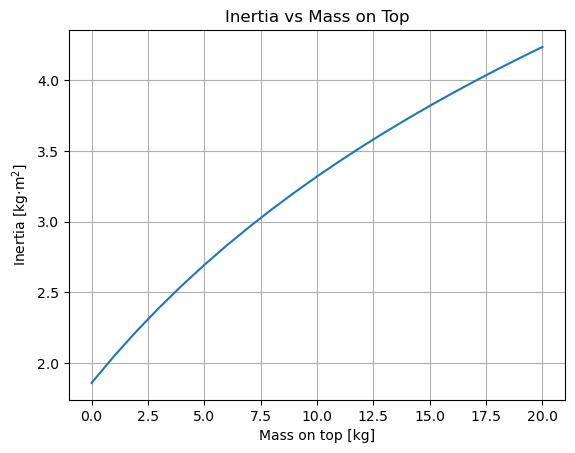

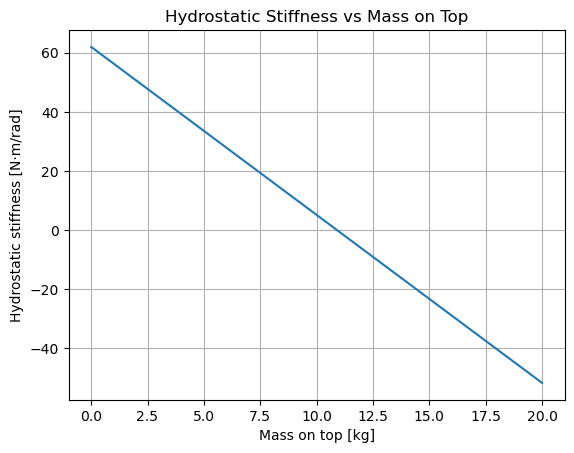

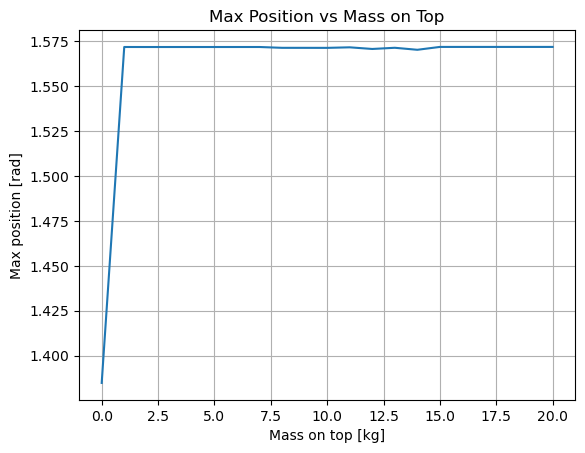

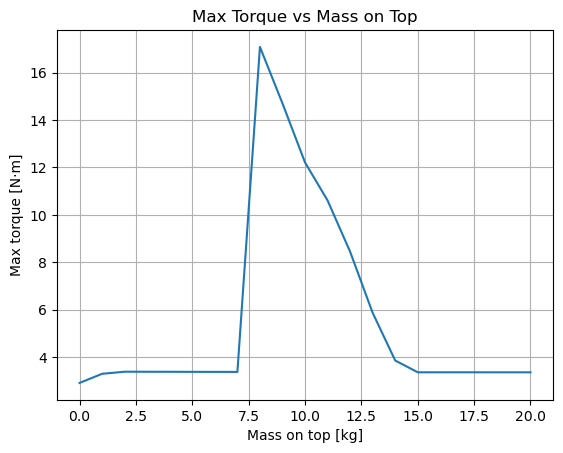

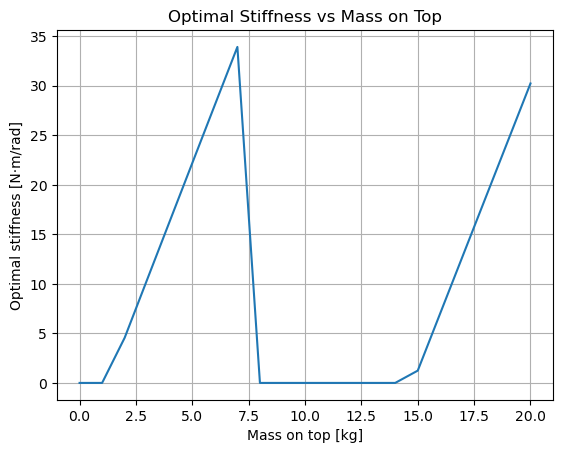

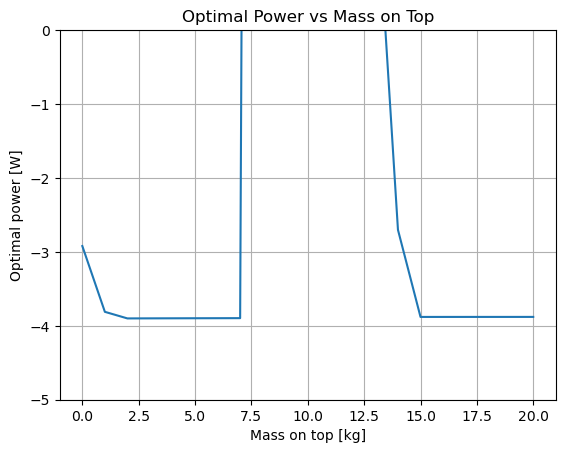

In [38]:
plt.figure()
plt.plot(mass_on_top_vec, cg_height_vals)
plt.xlabel("Mass on top [kg]")
plt.ylabel("CG height [m]")
plt.title("CG Height vs Mass on Top")
plt.grid(True)

plt.figure()
plt.plot(mass_on_top_vec, mass_vals)
plt.xlabel("Mass on top [kg]")
plt.ylabel("Total mass [kg]")
plt.title("Total Mass vs Mass on Top")
plt.grid(True)

plt.figure()
plt.plot(mass_on_top_vec, inertia_vals)
plt.xlabel("Mass on top [kg]")
plt.ylabel(r"Inertia [kg·m$^2$]")
plt.title("Inertia vs Mass on Top")
plt.grid(True)

plt.figure()
plt.plot(mass_on_top_vec, np.squeeze(hydrostatic_stiffness_vals))
plt.xlabel("Mass on top [kg]")
plt.ylabel("Hydrostatic stiffness [N·m/rad]")
plt.title("Hydrostatic Stiffness vs Mass on Top")
plt.grid(True)

plt.figure()
plt.plot(mass_on_top_vec, max_pos_vals)
plt.xlabel("Mass on top [kg]")
plt.ylabel("Max position [rad]")
plt.title("Max Position vs Mass on Top")
plt.grid(True)

plt.figure()
plt.plot(mass_on_top_vec, max_torque_vals)
plt.xlabel("Mass on top [kg]")
plt.ylabel("Max torque [N·m]")
plt.title("Max Torque vs Mass on Top")
plt.grid(True)

plt.figure()
plt.plot(mass_on_top_vec, opt_stiffness_vals)
plt.xlabel("Mass on top [kg]")
plt.ylabel("Optimal stiffness [N·m/rad]")
plt.title("Optimal Stiffness vs Mass on Top")
plt.grid(True)

plt.figure()
plt.plot(mass_on_top_vec, opt_power_vals)
plt.xlabel("Mass on top [kg]")
plt.ylabel("Optimal power [W]")
plt.title("Optimal Power vs Mass on Top")
plt.ylim([-5, 0])
plt.grid(True)